In [1]:
# Import required libraries

import os
import random
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Fix random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)



Using device: cpu


In [2]:
# Load raw Telco Churn dataset and basic cleaning

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print(df.head())
print(df.info())

# Convert TotalCharges to numeric (it sometimes contains spaces)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing TotalCharges after conversion
missing_before = df["TotalCharges"].isna().sum()
print("Missing TotalCharges before drop:", missing_before)
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print("Shape after dropping NaNs in TotalCharges:", df.shape)

# Check remaining missing values
print("Total missing values per column:\n", df.isna().sum())

# Convert target column 'Churn' to binary (Yes=1, No=0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

# Drop identifier column that should not be used as a feature
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df.head()


Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# Separate features and target, identify numeric and categorical columns

target_col = "Churn"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].values

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target positive ratio (Churn=1):", y.mean())


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target positive ratio (Churn=1): 0.26578498293515357


In [4]:
# Split into train/validation/test with stratification

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED
)  # 0.25 * 0.8 = 0.2

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

print("Churn ratio train:", y_train.mean())
print("Churn ratio val:", y_val.mean())
print("Churn ratio test:", y_test.mean())


Train size: 4218
Validation size: 1407
Test size: 1407
Churn ratio train: 0.26576576576576577
Churn ratio val: 0.2658137882018479
Churn ratio test: 0.2658137882018479


In [5]:
# Build preprocessing pipeline: standardize numeric features, one-hot encode categorical features

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Fit only on training data to avoid leakage
preprocessor.fit(X_train)

# Transform all splits
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed val shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

input_dim = X_train_processed.shape[1]
print("Input dimension for the ANN:", input_dim)


Processed train shape: (4218, 45)
Processed val shape: (1407, 45)
Processed test shape: (1407, 45)
Input dimension for the ANN: 45


In [6]:
# Convert preprocessed data into PyTorch tensors and build DataLoaders

class NumpyTensorDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = torch.from_numpy(X_np.astype(np.float32))
        self.y = torch.from_numpy(y_np.astype(np.float32)).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = NumpyTensorDataset(X_train_processed, y_train)
val_dataset = NumpyTensorDataset(X_val_processed, y_val)
test_dataset = NumpyTensorDataset(X_test_processed, y_test)

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Compute class weights for imbalance handling
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
neg_weight, pos_weight = class_weights
print("Class weights (0,1):", neg_weight, pos_weight)

pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32).to(DEVICE)


Class weights (0,1): 0.6809815950920245 1.88135593220339


In [7]:
# Define configurable feed-forward ANN, training loop with early stopping, and evaluation utilities

class FeedforwardNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_p=0.5):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # Binary classification logit
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_model(
    config,
    train_loader,
    val_loader,
    input_dim,
    pos_weight_tensor,
    device=DEVICE,
):
    
    #Train a model with a given hyperparameter configuration and return metrics and timing stats.
    
    hidden_dims = config["hidden_dims"]
    dropout_p = config["dropout"]
    lr = config["lr"]
    weight_decay = config["weight_decay"]
    num_epochs = config["num_epochs"]
    patience = config["patience"]

    model = FeedforwardNet(input_dim, hidden_dims, dropout_p=dropout_p).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_f1 = -np.inf
    best_state = None
    epochs_no_improve = 0

    train_start_time = time.perf_counter()

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
    }

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        all_logits = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                all_logits.append(logits.cpu())
                all_targets.append(y_batch.cpu())

        val_loss = val_loss / len(val_loader.dataset)
        all_logits = torch.cat(all_logits, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        probs = torch.sigmoid(all_logits).numpy().ravel()
        preds = (probs >= 0.5).astype(int)
        targets = all_targets.numpy().ravel()

        val_f1 = f1_score(targets, preds)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"[{config['name']}] Epoch {epoch}/{num_epochs} "
                f"- train_loss: {epoch_train_loss:.4f} "
                f"- val_loss: {val_loss:.4f} "
                f"- val_f1: {val_f1:.4f}"
            )

        # Early stopping based on validation F1
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} for config {config['name']}")
            break

    train_end_time = time.perf_counter()
    training_time = train_end_time - train_start_time

    # Load best state before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    num_params = count_trainable_params(model)

    # Approximate single-batch inference latency
    model.eval()
    example_batch, _ = next(iter(val_loader))
    example_batch = example_batch.to(device)

    torch.cuda.empty_cache() if device.type == "cuda" else None

    with torch.no_grad():
        start = time.perf_counter()
        _ = model(example_batch)
        end = time.perf_counter()
    inference_latency = (end - start) / example_batch.size(0)

    # Approximate memory footprint of model parameters in MB
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.nelement() * p.element_size()
    model_size_mb = total_bytes / (1024**2)

    metrics = {
        "best_val_f1": best_val_f1,
        "training_time_s": training_time,
        "inference_latency_s_per_sample": inference_latency,
        "num_params": num_params,
        "model_size_mb": model_size_mb,
        "history": history,
    }

    return model, metrics


def evaluate_model(model, data_loader, device=DEVICE, split_name="Test"):
    
    #Compute standard classification metrics on a given split.
    
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            all_logits.append(logits.cpu())
            all_targets.append(y_batch.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    probs = torch.sigmoid(all_logits).numpy().ravel()
    preds = (probs >= 0.5).astype(int)
    targets = all_targets.numpy().ravel()

    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds)
    rec = recall_score(targets, preds)
    f1 = f1_score(targets, preds)

    try:
        auc = roc_auc_score(targets, probs)
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(targets, preds)

    print(f"{split_name} metrics:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print("  Confusion matrix:\n", cm)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "confusion_matrix": cm,
    }


In [8]:
# Systematic exploration of several ANN architectures

experiment_configs = [
    {
        "name": "small_2x64_dropout0.3",
        "hidden_dims": [64, 64],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "num_epochs": 150,
        "patience": 15,
    },
    {
        "name": "medium_3x128_dropout0.4",
        "hidden_dims": [128, 128, 64],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 5e-4,
        "num_epochs": 200,
        "patience": 20,
    },
    {
        "name": "large_3x256_dropout0.5",
        "hidden_dims": [256, 128, 64],
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-3,
        "num_epochs": 200,
        "patience": 20,
    },
]

results = []
trained_models = {}

for cfg in experiment_configs:
    print("=" * 80)
    print("Training configuration:", cfg["name"])
    model, metrics = train_one_model(
        cfg,
        train_loader=train_loader,
        val_loader=val_loader,
        input_dim=input_dim,
        pos_weight_tensor=pos_weight_tensor,
        device=DEVICE,
    )
    trained_models[cfg["name"]] = model
    entry = {
        "name": cfg["name"],
        "hidden_dims": cfg["hidden_dims"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "best_val_f1": metrics["best_val_f1"],
        "training_time_s": metrics["training_time_s"],
        "inference_latency_s_per_sample": metrics["inference_latency_s_per_sample"],
        "num_params": metrics["num_params"],
        "model_size_mb": metrics["model_size_mb"],
    }
    results.append(entry)

results_df = pd.DataFrame(results).sort_values(by="best_val_f1", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df


Training configuration: small_2x64_dropout0.3
[small_2x64_dropout0.3] Epoch 1/150 - train_loss: 0.8114 - val_loss: 0.7584 - val_f1: 0.4570
[small_2x64_dropout0.3] Epoch 10/150 - train_loss: 0.5878 - val_loss: 0.6134 - val_f1: 0.6090
[small_2x64_dropout0.3] Epoch 20/150 - train_loss: 0.5662 - val_loss: 0.6136 - val_f1: 0.6181
Early stopping at epoch 20 for config small_2x64_dropout0.3
Training configuration: medium_3x128_dropout0.4
[medium_3x128_dropout0.4] Epoch 1/200 - train_loss: 0.8045 - val_loss: 0.7322 - val_f1: 0.2489
[medium_3x128_dropout0.4] Epoch 10/200 - train_loss: 0.5847 - val_loss: 0.6150 - val_f1: 0.6045
[medium_3x128_dropout0.4] Epoch 20/200 - train_loss: 0.5649 - val_loss: 0.6207 - val_f1: 0.6000
Early stopping at epoch 24 for config medium_3x128_dropout0.4
Training configuration: large_3x256_dropout0.5
[large_3x256_dropout0.5] Epoch 1/200 - train_loss: 0.8485 - val_loss: 0.8124 - val_f1: 0.3522
[large_3x256_dropout0.5] Epoch 10/200 - train_loss: 0.5990 - val_loss: 0.61

,name,hidden_dims,dropout,lr,weight_decay,best_val_f1,training_time_s,inference_latency_s_per_sample,num_params,model_size_mb
0,large_3x256_dropout0.5,"[256, 128, 64]",0.5,0.0005,0.0010,0.628159,4.318348,0.000003,52993,0.202152
1,small_2x64_dropout0.3,"[64, 64]",0.3,0.0010,0.0001,0.625604,1.876268,0.000002,7169,0.027348
2,medium_3x128_dropout0.4,"[128, 128, 64]",0.4,0.0010,0.0005,0.625000,3.425538,0.000002,30721,0.117191


In [9]:
# Select the best configuration based on validation F1 and retrain on train+val

best_row = results_df.iloc[0]
best_name = best_row["name"]
print("Best configuration based on validation F1:", best_name)

best_config = next(cfg for cfg in experiment_configs if cfg["name"] == best_name)

# Merge train and validation sets for final training
X_trainval_processed = preprocessor.transform(pd.concat([X_train, X_val], axis=0))
y_trainval = np.concatenate([y_train, y_val], axis=0)

trainval_dataset = NumpyTensorDataset(X_trainval_processed, y_trainval)
trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Recompute class weights on train+val
class_weights_trainval = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_trainval
)
neg_w_tv, pos_w_tv = class_weights_trainval
pos_weight_tv = torch.tensor([pos_w_tv], dtype=torch.float32).to(DEVICE)
print("Train+Val class weights (0,1):", neg_w_tv, pos_w_tv)

final_model, final_metrics = train_one_model(
    best_config,
    train_loader=trainval_loader,
    val_loader=val_loader,  # still monitor on original val for early stopping
    input_dim=input_dim,
    pos_weight_tensor=pos_weight_tv,
    device=DEVICE,
)

# Evaluate on test set
test_metrics = evaluate_model(final_model, test_loader, device=DEVICE, split_name="Test")


Best configuration based on validation F1: large_3x256_dropout0.5
Train+Val class weights (0,1): 0.6809927360774818 1.8812709030100334
[large_3x256_dropout0.5] Epoch 1/200 - train_loss: 0.8264 - val_loss: 0.7637 - val_f1: 0.1330
[large_3x256_dropout0.5] Epoch 10/200 - train_loss: 0.5966 - val_loss: 0.5982 - val_f1: 0.6291
[large_3x256_dropout0.5] Epoch 20/200 - train_loss: 0.5841 - val_loss: 0.5888 - val_f1: 0.6219
[large_3x256_dropout0.5] Epoch 30/200 - train_loss: 0.5759 - val_loss: 0.5818 - val_f1: 0.6168
[large_3x256_dropout0.5] Epoch 40/200 - train_loss: 0.5685 - val_loss: 0.5724 - val_f1: 0.6349
[large_3x256_dropout0.5] Epoch 50/200 - train_loss: 0.5701 - val_loss: 0.5634 - val_f1: 0.6513
[large_3x256_dropout0.5] Epoch 60/200 - train_loss: 0.5514 - val_loss: 0.5576 - val_f1: 0.6513
[large_3x256_dropout0.5] Epoch 70/200 - train_loss: 0.5453 - val_loss: 0.5470 - val_f1: 0.6601
[large_3x256_dropout0.5] Epoch 80/200 - train_loss: 0.5390 - val_loss: 0.5409 - val_f1: 0.6650
[large_3x25

In [10]:
# Additional efficiency analysis for the final model

final_model.eval()

# Measure latency on the full test set (batched)
def measure_inference_latency(model, data_loader, device=DEVICE, repeat=5):
    with torch.no_grad():
        latencies = []
        for _ in range(repeat):
            start = time.perf_counter()
            for X_batch, _ in data_loader:
                X_batch = X_batch.to(device)
                _ = model(X_batch)
            end = time.perf_counter()
            latencies.append(end - start)
    latencies = np.array(latencies)
    mean_latency = latencies.mean()
    std_latency = latencies.std()
    num_samples = len(data_loader.dataset)
    throughput = num_samples / mean_latency
    return {
        "mean_total_latency_s": mean_latency,
        "std_total_latency_s": std_latency,
        "num_samples": num_samples,
        "throughput_samples_per_s": throughput,
    }


eff_stats = measure_inference_latency(final_model, test_loader, device=DEVICE, repeat=5)
eff_stats


{'mean_total_latency_s': np.float64(0.01966984000027878),
 'std_total_latency_s': np.float64(0.002993261086826227),
 'num_samples': 1407,
 'throughput_samples_per_s': np.float64(71530.8309564317)}

In [11]:
# Plotting imports and basic style

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


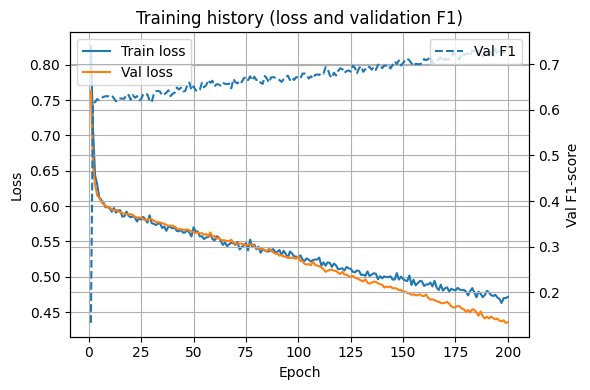

In [12]:
# Plot training history: train loss, val loss, val F1

history = final_metrics["history"]
epochs = range(1, len(history["train_loss"]) + 1)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.plot(epochs, history["train_loss"], label="Train loss")
ax1.plot(epochs, history["val_loss"], label="Val loss")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.set_ylabel("Val F1-score")
ax2.plot(epochs, history["val_f1"], label="Val F1", linestyle="--")
ax2.legend(loc="upper right")

plt.title("Training history (loss and validation F1)")
plt.tight_layout()
plt.show()


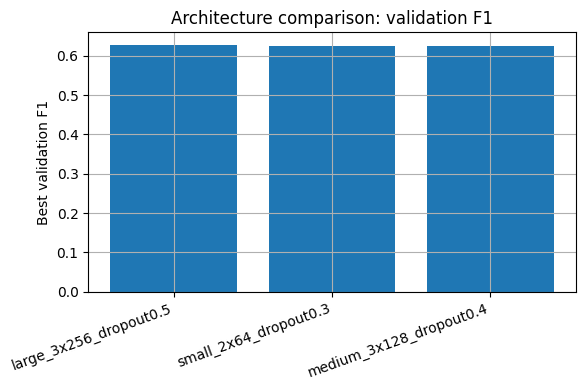

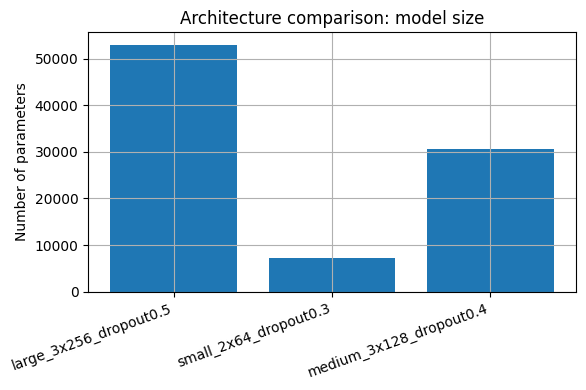

In [13]:
# Compare architectures: validation F1 vs number of parameters

names = results_df["name"].tolist()
val_f1 = results_df["best_val_f1"].tolist()
num_params = results_df["num_params"].tolist()

x = range(len(names))

fig, ax1 = plt.subplots()

ax1.bar(x, val_f1)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20, ha="right")
ax1.set_ylabel("Best validation F1")
ax1.set_title("Architecture comparison: validation F1")
plt.tight_layout()
plt.show()

# Optional: plot number of parameters (log scale if very different)
fig, ax2 = plt.subplots()
ax2.bar(x, num_params)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=20, ha="right")
ax2.set_ylabel("Number of parameters")
ax2.set_title("Architecture comparison: model size")
plt.tight_layout()
plt.show()


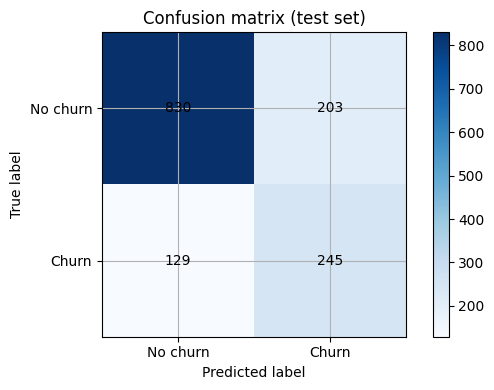

In [14]:
# Confusion matrix heatmap for the test set

cm = test_metrics["confusion_matrix"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix (test set)")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No churn", "Churn"])
ax.set_yticklabels(["No churn", "Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im)
plt.tight_layout()
plt.show()


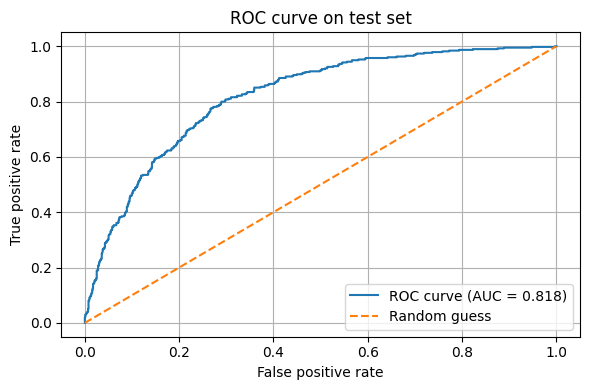

In [15]:
# ROC curve on the test set

from sklearn.metrics import roc_curve, auc

final_model.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = final_model(X_batch)
        all_logits.append(logits.cpu())
        all_targets.append(y_batch.cpu())

all_logits = torch.cat(all_logits, dim=0)
all_targets = torch.cat(all_targets, dim=0).numpy().ravel()

probs = torch.sigmoid(all_logits).numpy().ravel()
fpr, tpr, _ = roc_curve(all_targets, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve on test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
